# All concept papers downloaded, with field labels: `data.py` export demo

This notebook is a runnable walkthrough of **`data.py`**, the export script for the iteration-2 **concept-pool dataset** (artifact `art_eR1Z7fMlOcxs`).

**About the artifact.** The dataset covers the whole frozen frame of **426 concepts**: 366 emerging concepts first used in 2005–2016 plus 60 stationary reference concepts. For each concept it holds the complete list of OpenAlex works from 2000–2024, which comes to 462,812 works and 488,078 verified concept–work links. `data.py` builds **seven datasets** and converts each one into the `exp_sel_data_out` schema, with one `{input, output, metadata_*}` example per data row:

| # | dataset | source on the run volume |
|---|---|---|
| 1 | `concept_pool_2005_2016` | `hyd/data_out.json` |
| 2 | `concept_work_links` | `hyd/concept_work.parquet` |
| 3 | `openalex_works` | `hyd/works/*.parquet` |
| 4 | `subfield_year_totals` | `hyd/context/subfield_year_totals.json` |
| 5 | `nativeness_profiles` | `p2/profiles.jsonl` |
| 6 | `nativeness_coverage` | `outputs/nativeness_coverage.json` |
| 7 | `venue_habitat_asjc` | `outputs/venue_habitat_asjc.json` |

The script then splits the examples into parts smaller than 90 MB (`full_data_out/full_data_out_N.json`). For each part, and for the whole export, it also writes a `mini_*` file (3 examples per dataset) and a `preview_*` file (strings truncated to 200 characters).

**What this demo runs.** The raw sources total several GB and stay on the run's storage volume, so the demo loads **`mini_demo_data.json`**. That file holds 100 raw venue records, sampled by stratum from the 22,970 records in dataset (7) **`venue_habitat_asjc`**. This dataset gives each journal a *habitat* subfield taken from its SCImago/Scopus ASJC categories. The rule was fixed before any outcomes were examined:
- one specific subfield → COVERED;
- several subfields → UNCOVERED(`multi_subfield`), with fractional shares of 1/k;
- repositories and megajournals → UNCOVERED;
- venues not matched in SCImago → a pre-period topic fallback, applied only when the venue has at least 20 c-papers.

The rest of `data.py` is copied **unchanged**: `ds_venues`, `TOP_META`, `trunc`, `write_small`, `write_parts` and `main`. The other builders are also copied so you can read them, but they are not called here because their raw inputs are not part of the demo data.

In [1]:
%%capture
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# orjson, loguru — NOT pre-installed on Colab, always install
_pip('orjson==3.10.18', 'loguru==0.7.3')

# pyarrow, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'pyarrow==18.1.0', 'matplotlib==3.10.0')

## Imports
This is the original import block from `data.py`. Two extra imports are needed only for the results cell: `pandas` and `matplotlib`.

In [2]:
import sys
from pathlib import Path

import orjson
import pyarrow.parquet as pq
from loguru import logger

# --- notebook-only additions (results / visualisation) ---
import json
from types import SimpleNamespace
import pandas as pd
import matplotlib.pyplot as plt

## Load the demo data
The notebook first tries the file on GitHub (this is what runs on Colab) and falls back to a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_F1tk5OGtH84L/round-2/dataset-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            d = json.loads(response.read().decode())
            if "venue_habitat_asjc" in d: return d  # guard against a stale file at the URL
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("venue records in demo:", len(data["venue_habitat_asjc"]["venues"]), "of", data["venue_habitat_asjc"]["n_venues"])

Demo subset of the RAW source of dataset (7) venue_habitat_asjc (outputs/venue_habitat_asjc.json): 100 of 22,970 venue records, stratified by (route, uncovered_reason) - top-n_c_papers venues plus a seeded random sample per stratum. data.py's ds_venues() turns each record into one exp_sel_data_out example.
venue records in demo: 100 of 22970


## Config
These are all the tunable parameters. The demo uses the full 100-record sample and a *small* part limit, so `write_parts` actually splits the output into several files. To reproduce the real export, set `PART_LIMIT = 85_000_000` and run `data.py` against all 22,970 venues and the other six sources.

In [5]:
N_VENUES = 100            # venue records converted (demo max 100; original: all 22,970)
PART_LIMIT = 20_000       # bytes per full_data_out part (original: 85_000_000)
MINI_N = 3                # examples per dataset in mini_*/preview_* files (original: 3, hard-coded in write_small)
PREVIEW_CHARS = 200       # string truncation for preview_* files (original: 200, default of trunc)
OUT_ROOT = "demo_out"     # where the notebook writes its outputs (original: the script's own directory)

## Setup: paths, the `hyd/data.py` helper module, and logging
In the original script, `ROOT` is the script's own directory, and `import data as d1` loads the iteration-1 builders from `hyd/data.py`. Only three constants from that module matter for this dataset: `LINK_FEATURES`, `WORK_FEATURES` and `TOP_META["notes"]`. They are stored in the demo data, so a small `SimpleNamespace` stands in for `d1`. This is the **only structural change** to the script. `J` and the loguru setup (stdout sink plus a rotating file sink) are unchanged.

In [6]:
ROOT = Path(OUT_ROOT).resolve()          # original: Path(__file__).resolve().parent
ROOT.mkdir(exist_ok=True)
HYD = ROOT / "hyd"
# original: sys.path.insert(0, str(HYD)); import data as d1  (hyd/data.py: dataset_1 builders, ROOT = hyd/)
_c = data["hyd_data_constants"]
d1 = SimpleNamespace(LINK_FEATURES=_c["LINK_FEATURES"], WORK_FEATURES=_c["WORK_FEATURES"],
                     TOP_META={"notes": _c["TOP_META_notes"]})

# PART_LIMIT = 85_000_000  -> now set in the config cell
J = lambda o: orjson.dumps(o).decode()  # noqa: E731

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")

2

## Builders for datasets 3, 5 and 6 (defined but not run here)
These are copied verbatim. They read `hyd/works/*.parquet`, `p2/profiles.jsonl` and `outputs/nativeness_coverage.json`, which are not included in the demo data. The functions show the row → example mapping:
- `ds_works` turns each OpenAlex work into an `input` JSON array, ordered as `WORK_FEATURES`. Its `output` is the primary-topic subfield id, or `"unknown"`.
- `ds_profiles` produces one row per (legacy-concept node, 5-year block) with exact OpenAlex subfield counts.
- `ds_coverage` produces one row per pool concept giving the share of host co-occurrence weight covered by nativeness profiles, plus an `__OVERALL__` row.

In [7]:
def ds_works() -> list[dict]:
    out = []
    cols = d1.WORK_FEATURES + ["subfield_id", "field_id", "domain_id", "retrieval_batch"]
    for p in sorted((HYD / "works").glob("works_part_*.parquet")):
        for r in pq.read_table(p, columns=cols).to_pylist():
            if r["topic_score"] is not None:
                r["topic_score"] = round(float(r["topic_score"]), 4)
            sf = r["subfield_id"]
            out.append({"input": J([r[k] for k in d1.WORK_FEATURES]),
                        "output": str(sf) if sf is not None else "unknown",
                        "metadata_field_id": r["field_id"], "metadata_domain_id": r["domain_id"],
                        "metadata_retrieval_batch": r["retrieval_batch"]})
    return out


def ds_profiles() -> list[dict]:
    out = []
    p = ROOT / "p2" / "profiles.jsonl"
    rows = [orjson.loads(x) for x in p.read_text().splitlines() if x.strip()] if p.exists() else []
    rows.sort(key=lambda r: (r["coverage_rank"], r["block"]))
    for r in rows:
        inp = {"node_id": r["node_id"], "node_type": r["node_type"], "display_name": r["display_name"],
               "level": r["level"], "block": r["block"]}
        outp = {"total": r["total"], "subfield_counts": r["subfield_counts"], "n_groups": r["n_groups"],
                "truncated_top200": r["truncated_top200"]}
        out.append({"input": J(inp), "output": J(outp), "metadata_coverage_rank": r["coverage_rank"],
                    "metadata_host_cooc_weight": r["host_cooc_weight"],
                    "metadata_cum_weight_share": round(r["cum_weight_share"], 6), "metadata_frame": r["frame"],
                    "metadata_retrieved_utc": r["retrieved_utc"], "metadata_credits": r["credits"],
                    "metadata_request_filter": r["request_filter"]})
    return out


def ds_coverage() -> list[dict]:
    d = orjson.loads((ROOT / "outputs" / "nativeness_coverage.json").read_bytes())
    out = []
    for r in d["concepts"]:
        out.append({"input": J({"concept_id": r["concept_id"], "origin_subfield": r["origin_subfield"]}),
                    "output": J({"covered_weight_share": r["covered_weight_share"],
                                 "n_host_cpapers": r["n_host_cpapers"], "n_distinct_nodes": r["n_distinct_nodes"],
                                 "host_weight": r["host_weight"]}),
                    "metadata_phrase": r["phrase"], "metadata_arm": r["arm"], "metadata_origin_rule": r["origin_rule"]})
    o = d["overall"]
    out.append({"input": J({"concept_id": "__OVERALL__", "origin_subfield": None}), "output": J(o),
                "metadata_phrase": None, "metadata_arm": "overall", "metadata_origin_rule": None})
    return out

## Dataset 7: `venue_habitat_asjc` builder (runs on the demo data)
Each venue record becomes one example:
- **input**: venue identity (OpenAlex `source_id`, ISSNs, name and type).
- **output**: `habitat_subfield`, which is a 4-digit ASJC code (equal to the OpenAlex subfield id) or `"UNCOVERED"`. It also includes the 1/k `fractional_shares` for multi-subfield journals and the raw ASJC codes.
- **metadata_***: the rule route (`scimago`, `preperiod_groupby` or `none`), the SJR year used (the one nearest 2010), the reason a venue is uncovered, the number of c-papers, and whether the label is citation-independent.

The only change is on the first line. The function reads the records from `data` instead of `outputs/venue_habitat_asjc.json`, keeping the first `N_VENUES`.

In [8]:
def ds_venues() -> list[dict]:
    # original: d = orjson.loads((ROOT / "outputs" / "venue_habitat_asjc.json").read_bytes())
    d = {**data["venue_habitat_asjc"], "venues": data["venue_habitat_asjc"]["venues"][:N_VENUES]}
    out = []
    for v in d["venues"]:
        inp = {"source_id": v["source_id"], "issn_l": v.get("issn_l"), "issns": v.get("issns"),
               "display_name": v.get("display_name"), "openalex_type": v.get("openalex_type")}
        outp = {"habitat_subfield": v["habitat_subfield"], "fractional_shares": v["fractional_shares"],
                "asjc_codes_raw": v["asjc_codes_raw"]}
        out.append({"input": J(inp), "output": J(outp), "metadata_route": v["route"],
                    "metadata_sjr_year_used": v["sjr_year_used"], "metadata_uncovered_reason": v["uncovered_reason"],
                    "metadata_n_c_papers": v["n_c_papers"], "metadata_citation_independent": v["citation_independent"],
                    "metadata_habitat_in_openalex_subfields": v.get("habitat_in_openalex_subfields"),
                    "metadata_asjc_codes_union_2005_2010_2015_2019": J(v.get("asjc_codes_union_2005_2010_2015_2019")),
                    "metadata_scopus_source_ids": J(v.get("scopus_source_ids")),
                    "metadata_general_field": v.get("general_field"),
                    "metadata_preperiod_dominant_share": v.get("preperiod_dominant_share")})
    return out

## Top-level metadata and the mini/preview helpers
`TOP_META` is written at the top of every output file. It combines the feature names inherited from `hyd/data.py` with notes for each dataset. `trunc` truncates every string recursively, which is how the `preview_*` files are made. `write_small` writes the `mini_*` file (the first 3 examples per dataset) and its truncated `preview_*` version.

In [9]:
TOP_META = {
    "description": "Iteration-2 concept-pool artifact (see README.md). One example per data row, grouped by dataset.",
    "feature_names": {"concept_work_links": d1.LINK_FEATURES, "openalex_works": d1.WORK_FEATURES},
    "notes": {**d1.TOP_META["notes"],
              "subfield_year_totals": "dataset_1 D4 copied unchanged; the 'all_types' variant is the per-10^4 "
                                      "denominator (c-papers include every work type)",
              "nativeness_profiles": "exact OpenAlex meta.count and group_by counts, never sample-based; frame = all "
                                     "types; 'unknown' = works without a primary topic",
              "venue_habitat_asjc": "habitat_subfield = 4-digit ASJC code (= OpenAlex subfield id where one exists) "
                                    "or 'UNCOVERED'; route preperiod_groupby is NOT citation-independent"}}


def trunc(o, n: int = PREVIEW_CHARS):
    """Preview variant: every string truncated to n characters (recursively)."""
    if isinstance(o, str):
        return o if len(o) <= n else o[:n] + "..."
    if isinstance(o, list):
        return [trunc(x, n) for x in o]
    if isinstance(o, dict):
        return {k: trunc(v, n) for k, v in o.items()}
    return o


def write_small(path_stem: Path, datasets: list[dict]) -> None:
    """mini_* (3 examples per dataset) and preview_* (mini with strings truncated to 200 chars)."""
    mini = {"metadata": TOP_META, "datasets": [{"dataset": d["dataset"], "examples": d["examples"][:MINI_N]}
                                               for d in datasets]}
    (path_stem.parent / f"mini_{path_stem.name}.json").write_bytes(orjson.dumps(mini, option=orjson.OPT_INDENT_2))
    (path_stem.parent / f"preview_{path_stem.name}.json").write_bytes(
        orjson.dumps(trunc(mini), option=orjson.OPT_INDENT_2))

## Splitting into size-limited parts
`write_parts` streams through all examples and starts a new part whenever adding the next example would push the current part past `PART_LIMIT` bytes. One dataset can therefore span several parts, and a part can hold the tail of one dataset and the head of the next. Each part gets its own mini and preview files. In the demo `PART_LIMIT` is small, so you can watch the split happen.

In [10]:
def write_parts(datasets: list[dict]) -> None:
    out_dir = ROOT / "full_data_out"
    out_dir.mkdir(exist_ok=True)
    for old in sorted(out_dir.glob("*.json")):
        old.unlink()
    parts, cur, size = [], [], 0
    for d in datasets:
        chunk = []
        for e in d["examples"]:
            b = len(orjson.dumps(e)) + 1
            if size + b > PART_LIMIT and (chunk or cur):
                if chunk:
                    cur.append({"dataset": d["dataset"], "examples": chunk})
                parts.append(cur)
                cur, chunk, size = [], [], 0
            chunk.append(e)
            size += b
        if chunk:
            cur.append({"dataset": d["dataset"], "examples": chunk})
    if cur:
        parts.append(cur)
    for k, p in enumerate(parts, 1):
        (out_dir / f"full_data_out_{k}.json").write_bytes(orjson.dumps({"metadata": TOP_META, "datasets": p}))
        write_small(out_dir / f"data_out_{k}", p)
        logger.info(f"part {k}: " + ", ".join(f"{x['dataset']}={len(x['examples'])}" for x in p))
    logger.info(f"wrote {len(parts)} parts to full_data_out/")

## `main()`: build every dataset, then write the parts and the root mini/preview files
This is the original `main`. The six builders whose raw inputs are not in the demo data are commented out of `builders`, so only `venue_habitat_asjc` is exported. The original also skips any dataset that has no rows.

In [11]:
@logger.catch(reraise=True)
def main() -> None:
    # cm = d1.concept_meta()   # needs hyd/data_out.json (not in the demo data)
    builders = {
        # "concept_pool_2005_2016": d1.ds_concept_pool,
        # "concept_work_links": lambda: d1.ds_links(cm),
        # "openalex_works": ds_works,
        # "subfield_year_totals": d1.ds_denominators,
        # "nativeness_profiles": ds_profiles,
        # "nativeness_coverage": ds_coverage,
        "venue_habitat_asjc": ds_venues,
    }
    datasets = []
    for n, fn in builders.items():
        ex = fn()
        logger.info(f"{n}: {len(ex)} examples")
        if not ex:
            logger.warning(f"{n}: no rows yet, dataset left out of this export")
            continue
        datasets.append({"dataset": n, "examples": ex})
    write_parts(datasets)
    write_small(ROOT / "data_out", datasets)  # root mini_data_out.json / preview_data_out.json: 3 per dataset


main()

03:23:25|INFO   |venue_habitat_asjc: 100 examples


03:23:25|INFO   |part 1: venue_habitat_asjc=28


03:23:25|INFO   |part 2: venue_habitat_asjc=30


03:23:26|INFO   |part 3: venue_habitat_asjc=29


03:23:26|INFO   |part 4: venue_habitat_asjc=13


03:23:26|INFO   |wrote 4 parts to full_data_out/


## Results
The cells below read back what `main()` wrote:
1. The output files, with their sizes and example counts.
2. A few exported examples, decoded from their `input` and `output` JSON strings.
3. How the venue-habitat rule labelled the demo venues, both counted by venue and weighted by c-papers.

In the full dataset, only 2,929 of the 22,970 venues are COVERED, which covers just 12.1% of concept–work links. The main reasons are multi-category journals and arXiv. Because the demo sample is stratified, its proportions do not match the full dataset's.

In [12]:
# 1) files written by the export
rows = []
for p in sorted(ROOT.rglob("*.json")):
    d = json.loads(p.read_text())
    rows.append({"file": str(p.relative_to(ROOT)), "bytes": p.stat().st_size,
                 "examples": sum(len(x["examples"]) for x in d["datasets"])})
print(pd.DataFrame(rows).to_string(index=False))

# 2) decoded examples of the full export
full = [json.loads(p.read_text()) for p in sorted((ROOT / "full_data_out").glob("full_data_out_*.json"))]
ex = [e for f in full for d in f["datasets"] for e in d["examples"]]
tab = pd.DataFrame([{**json.loads(e["input"]), **json.loads(e["output"]),
                     **{k[9:]: v for k, v in e.items() if k.startswith("metadata_")}} for e in ex])
pd.set_option("display.width", 200, "display.max_colwidth", 40)
print()
print(tab[["display_name", "openalex_type", "route", "habitat_subfield", "uncovered_reason",
           "n_c_papers", "citation_independent"]].head(15).to_string(index=False))

                                 file  bytes  examples
   full_data_out/full_data_out_1.json  20680        28
   full_data_out/full_data_out_2.json  21258        30
   full_data_out/full_data_out_3.json  20791        29
   full_data_out/full_data_out_4.json  10155        13
   full_data_out/mini_data_out_1.json   4195         3
   full_data_out/mini_data_out_2.json   4280         3
   full_data_out/mini_data_out_3.json   4114         3
   full_data_out/mini_data_out_4.json   4144         3
full_data_out/preview_data_out_1.json   4195         3
full_data_out/preview_data_out_2.json   4213         3
full_data_out/preview_data_out_3.json   4114         3
full_data_out/preview_data_out_4.json   4144         3
                   mini_data_out.json   4195         3
                preview_data_out.json   4195         3

                                                                              display_name openalex_type             route habitat_subfield        uncovered_reason  n_c_paper

            route                             status  venues  c_papers
             none          UNCOVERED: no_match_small      27       288
          scimago          UNCOVERED: multi_subfield      23     25347
          scimago                            COVERED      15     17544
          scimago            UNCOVERED: general_only      11     10040
             none              UNCOVERED: repository      10     39596
preperiod_groupby            UNCOVERED: no_preperiod       4      1112
          scimago             UNCOVERED: megajournal       3      6937
preperiod_groupby UNCOVERED: preperiod_share_le_0.40       3      3622
preperiod_groupby                            COVERED       2      1419
          scimago   UNCOVERED: unmapped_sjr_category       2      1525

c-paper share in COVERED venues (demo sample): 17.7%


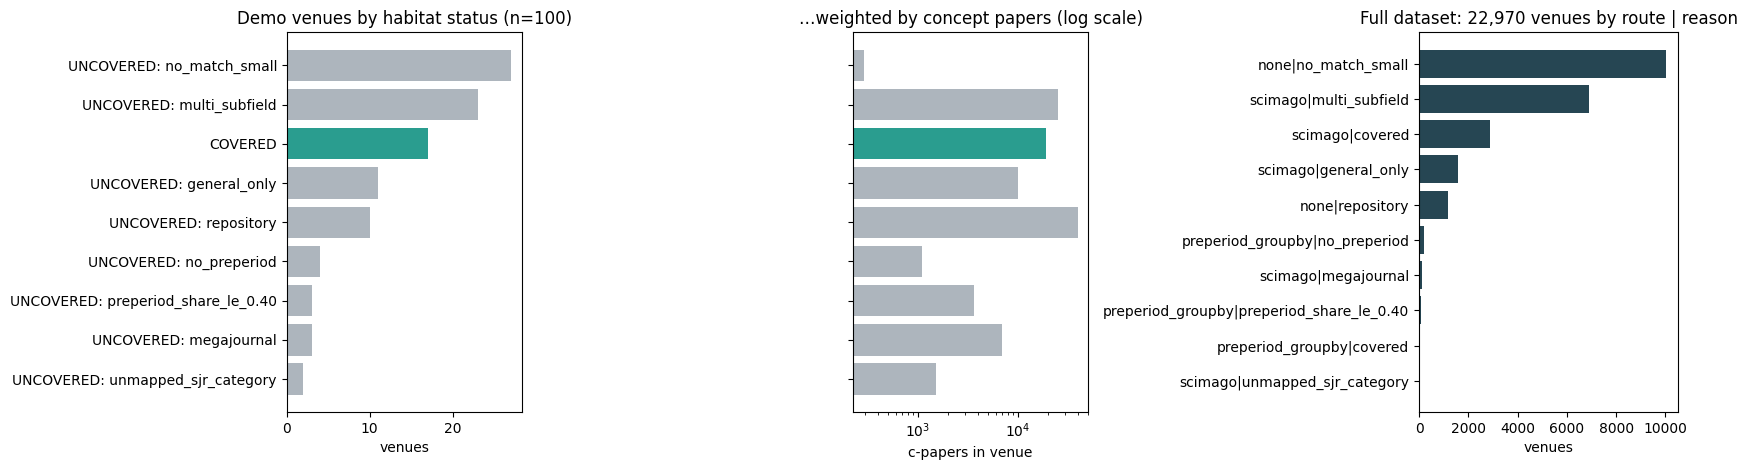

In [13]:
# 3) how the habitat rule labelled the demo venues
tab["status"] = tab.apply(lambda r: "COVERED" if r["habitat_subfield"] != "UNCOVERED"
                          else f"UNCOVERED: {r['uncovered_reason']}", axis=1)
summary = (tab.groupby(["route", "status"])
              .agg(venues=("source_id", "size"), c_papers=("n_c_papers", "sum")).reset_index()
              .sort_values("venues", ascending=False))
print(summary.to_string(index=False))
print(f"\nc-paper share in COVERED venues (demo sample): "
      f"{tab.loc[tab.status == 'COVERED', 'n_c_papers'].sum() / tab.n_c_papers.sum():.1%}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), gridspec_kw={"width_ratios": [1, 1, 1.1]})
by_status = tab.groupby("status").agg(venues=("source_id", "size"), c_papers=("n_c_papers", "sum"))
by_status = by_status.sort_values("venues")
colors = ["#2a9d8f" if s == "COVERED" else "#adb5bd" for s in by_status.index]
axes[0].barh(by_status.index, by_status.venues, color=colors)
axes[0].set_title(f"Demo venues by habitat status (n={len(tab)})")
axes[0].set_xlabel("venues")
axes[1].barh(by_status.index, by_status.c_papers, color=colors)
axes[1].set_xscale("log")
axes[1].set_title("…weighted by concept papers (log scale)")
axes[1].set_xlabel("c-papers in venue")
axes[1].set_yticklabels([])
full_sizes = pd.Series(data["full_stratum_sizes"]).rename(lambda k: k.replace("|None", "|covered")).sort_values()
axes[2].barh(full_sizes.index, full_sizes.values, color="#264653")
axes[2].set_title("Full dataset: 22,970 venues by route | reason")
axes[2].set_xlabel("venues")
plt.tight_layout()
plt.show()